**Tatoeba Dataset Download + Preprocessing**

In [ ]:
# =========================
# Dataset Collection (Tatoeba) + Preprocessing  
# =========================

import urllib.request
import tarfile
import os
import re

# Create data directory
os.makedirs("tatoeba", exist_ok=True)

# Download sentence files
urllib.request.urlretrieve(
    "https://downloads.tatoeba.org/exports/sentences.tar.bz2",
    "tatoeba/sentences.tar.bz2"
)

urllib.request.urlretrieve(
    "https://downloads.tatoeba.org/exports/links.tar.bz2",
    "tatoeba/links.tar.bz2"
)

# Extract archives
with tarfile.open("tatoeba/sentences.tar.bz2", "r:bz2") as tar:
    tar.extractall("tatoeba")

with tarfile.open("tatoeba/links.tar.bz2", "r:bz2") as tar:
    tar.extractall("tatoeba")

# Load sentences
sentences = {}
with open("tatoeba/sentences.csv", encoding="utf-8") as f:
    for line in f:
        sid, lang, text = line.strip().split("\t")
        sentences[sid] = (lang, text)

english_sentences = []
french_sentences = []

# Load links and extract EN–FR pairs
with open("tatoeba/links.csv", encoding="utf-8") as f:
    for line in f:
        id1, id2 = line.strip().split("\t")
        if id1 in sentences and id2 in sentences:
            lang1, text1 = sentences[id1]
            lang2, text2 = sentences[id2]

            if lang1 == "eng" and lang2 == "fra":
                english_sentences.append(text1)
                french_sentences.append(text2)
            elif lang1 == "fra" and lang2 == "eng":
                english_sentences.append(text2)
                french_sentences.append(text1)

        if len(english_sentences) >= 500:
            break

# Preprocessing
def preprocess(corpus):
    processed = []
    for sentence in corpus:
        sentence = sentence.lower()
        sentence = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", "", sentence)
        processed.append(sentence.split())
    return processed

english_tokens = preprocess(english_sentences)
french_tokens = preprocess(french_sentences)

# Sanity check
print("Aligned sentence pairs:", len(english_tokens))
print("English sample:", english_tokens[0])
print("French sample:", french_tokens[0])


/tmp/ipython-input-3860469147.py:27: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("tatoeba")
/tmp/ipython-input-3860469147.py:30: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("tatoeba")


Aligned sentence pairs: 500
English sample: ['when', 'he', 'asked', 'who', 'had', 'broken', 'the', 'window', 'all', 'the', 'boys', 'put', 'on', 'an', 'air', 'of', 'innocence']
French sample: ['lorsquil', 'a', 'demandé', 'qui', 'avait', 'cassé', 'la', 'fenêtre', 'tous', 'les', 'garçons', 'ont', 'pris', 'un', 'air', 'innocent']


**One-Hot Encoding**

In [ ]:
# =========================
# One-Hot Encoding  
# =========================

from sklearn.preprocessing import OneHotEncoder

# Build vocabularies
english_vocab = sorted(set(word for sentence in english_tokens for word in sentence))
french_vocab = sorted(set(word for sentence in french_tokens for word in sentence))

# Initialize encoders (NEW PARAMETER NAME)
onehot_en = OneHotEncoder(sparse_output=False)
onehot_fr = OneHotEncoder(sparse_output=False)

# Fit encoders
onehot_en.fit([[w] for w in english_vocab])
onehot_fr.fit([[w] for w in french_vocab])

# Example vectors
en_example = onehot_en.transform([["window"]])[0]
fr_example = onehot_fr.transform([["fenêtre"]])[0]

print("English vocab size:", len(english_vocab))
print("French vocab size:", len(french_vocab))
print("One-hot vector length (EN):", len(en_example))
print("One-hot vector length (FR):", len(fr_example))


English vocab size: 744
French vocab size: 995
One-hot vector length (EN): 744
One-hot vector length (FR): 995


**TF-IDF Vectorization**

In [ ]:
# =========================
# TF-IDF Vectorization
# =========================

from sklearn.feature_extraction.text import TfidfVectorizer

# Convert tokenized sentences back to strings
english_text = [" ".join(sentence) for sentence in english_tokens]
french_text = [" ".join(sentence) for sentence in french_tokens]

# Initialize TF-IDF vectorizers
tfidf_en = TfidfVectorizer()
tfidf_fr = TfidfVectorizer()

# Fit and transform
X_en_tfidf = tfidf_en.fit_transform(english_text)
X_fr_tfidf = tfidf_fr.fit_transform(french_text)

# Sanity check
print("TF-IDF English shape:", X_en_tfidf.shape)
print("TF-IDF French shape:", X_fr_tfidf.shape)


TF-IDF English shape: (500, 741)
TF-IDF French shape: (500, 991)


**Word2Vec**

In [ ]:
!pip install -q gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.1 MB/s eta 0:00:00


In [ ]:
# =========================
# Word2Vec Embeddings
# =========================

from gensim.models import Word2Vec

# Train Word2Vec models
w2v_en = Word2Vec(
    sentences=english_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

w2v_fr = Word2Vec(
    sentences=french_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

# Sanity check
print("Word2Vec EN vocab size:", len(w2v_en.wv))
print("Word2Vec FR vocab size:", len(w2v_fr.wv))
print("Sample EN vector (window):", w2v_en.wv["window"][:5])
print("Sample FR vector (fenêtre):", w2v_fr.wv["fenêtre"][:5])


Word2Vec EN vocab size: 407
Word2Vec FR vocab size: 431
Sample EN vector (window): [-0.0048378   0.00864469  0.00918868 -0.00874314  0.01000938]
Sample FR vector (fenêtre): [-0.00418437  0.01031792  0.0026968  -0.00970205  0.00319122]


**GloVe**

In [ ]:
# =========================
# GloVe Embeddings
# =========================

import numpy as np
from collections import Counter, defaultdict

# Build vocabulary indices
def build_vocab(tokens):
    vocab = {}
    for sentence in tokens:
        for word in sentence:
            if word not in vocab:
                vocab[word] = len(vocab)
    return vocab

# Build co-occurrence matrix
def build_cooccurrence(tokens, vocab, window_size=5):
    cooc = defaultdict(float)
    for sentence in tokens:
        indices = [vocab[w] for w in sentence if w in vocab]
        for center_i, center in enumerate(indices):
            start = max(0, center_i - window_size)
            end = min(len(indices), center_i + window_size + 1)
            for i in range(start, end):
                if i != center_i:
                    cooc[(center, indices[i])] += 1.0
    return cooc

# Simple GloVe training
def train_glove(cooc, vocab_size, vector_size=50, epochs=25, lr=0.05):
    W = np.random.rand(vocab_size, vector_size)
    for _ in range(epochs):
        for (i, j), x in cooc.items():
            diff = W[i] - W[j]
            W[i] -= lr * diff
            W[j] += lr * diff
    return W

# English GloVe
glove_vocab_en = build_vocab(english_tokens)
cooc_en = build_cooccurrence(english_tokens, glove_vocab_en)
glove_en = train_glove(cooc_en, len(glove_vocab_en))

# French GloVe
glove_vocab_fr = build_vocab(french_tokens)
cooc_fr = build_cooccurrence(french_tokens, glove_vocab_fr)
glove_fr = train_glove(cooc_fr, len(glove_vocab_fr))

# Sanity check
print("GloVe EN vocab size:", len(glove_vocab_en))
print("GloVe FR vocab size:", len(glove_vocab_fr))
print("Sample EN vector (window):", glove_en[glove_vocab_en["window"]][:5])
print("Sample FR vector (fenêtre):", glove_fr[glove_vocab_fr["fenêtre"]][:5])


GloVe EN vocab size: 744
GloVe FR vocab size: 995
Sample EN vector (window): [0.49986535 0.50477    0.48713653 0.51037711 0.48432327]
Sample FR vector (fenêtre): [0.49846423 0.48915938 0.51131496 0.49997783 0.50799242]


**FastText**

In [ ]:
# =========================
# FastText Embeddings
# =========================

from gensim.models import FastText

# Train FastText models
ft_en = FastText(
    sentences=english_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

ft_fr = FastText(
    sentences=french_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

# Sanity check
print("FastText EN vocab size:", len(ft_en.wv))
print("FastText FR vocab size:", len(ft_fr.wv))
print("Sample EN vector (window):", ft_en.wv["window"][:5])
print("Sample FR vector (fenêtre):", ft_fr.wv["fenêtre"][:5])


FastText EN vocab size: 407
FastText FR vocab size: 431
Sample EN vector (window): [ 0.00030766  0.00156063 -0.00100372 -0.00055179 -0.00047006]
Sample FR vector (fenêtre): [ 0.00202351 -0.00067577  0.00202074 -0.0012203   0.00313311]


In [ ]:
# =========================
# Multilingual Alignment using a bilingual dictionary
# =========================

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.linalg import orthogonal_procrustes

# Step 1: Build a bilingual dictionary from aligned Tatoeba data
bilingual_pairs = []

for en_sent, fr_sent in zip(english_tokens, french_tokens):
    for en_word, fr_word in zip(en_sent, fr_sent):
        if en_word in w2v_en.wv and fr_word in w2v_fr.wv:
            bilingual_pairs.append((en_word, fr_word))
    if len(bilingual_pairs) >= 100:
        break

# Remove duplicates
bilingual_pairs = list(set(bilingual_pairs))

# Step 2: Build embedding matrices
X = np.array([w2v_en.wv[en] for en, _ in bilingual_pairs])
Y = np.array([w2v_fr.wv[fr] for _, fr in bilingual_pairs])

# Step 3: Learn alignment matrix (Orthogonal Procrustes)
R, _ = orthogonal_procrustes(X, Y)

# Step 4: Evaluate alignment using cosine similarity
def aligned_similarity(en_word, fr_word):
    en_vec = np.dot(w2v_en.wv[en_word], R).reshape(1, -1)
    fr_vec = w2v_fr.wv[fr_word].reshape(1, -1)
    return cosine_similarity(en_vec, fr_vec)[0][0]

# Display sample similarities
print("Sample alignment evaluation:")
for en_word, fr_word in bilingual_pairs[:10]:
    sim = aligned_similarity(en_word, fr_word)
    print(f"{en_word} ↔ {fr_word} | cosine similarity = {sim:.3f}")


Sample alignment evaluation:
is ↔ a | cosine similarity = 0.710
the ↔ garçons | cosine similarity = 0.429
boys ↔ ont | cosine similarity = 0.740
birthday ↔ de | cosine similarity = 0.422
and ↔ et | cosine similarity = 0.718
will ↔ serai | cosine similarity = 0.764
asked ↔ qui | cosine similarity = 0.593
broken ↔ cassé | cosine similarity = 0.482
something ↔ chose | cosine similarity = 0.913
cant ↔ ne | cosine similarity = 0.854


**Multilingual Alignment**

In [ ]:
# =========================
# Download MUSE bilingual dictionary
# =========================

import urllib.request
import os

os.makedirs("muse", exist_ok=True)

muse_dict_url = "https://dl.fbaipublicfiles.com/arrival/dictionaries/en-fr.txt"
muse_dict_path = "muse/en-fr.txt"

urllib.request.urlretrieve(muse_dict_url, muse_dict_path)

print("MUSE dictionary downloaded:", muse_dict_path)


MUSE dictionary downloaded: muse/en-fr.txt


In [ ]:
# =========================
# Multilingual Alignment using MUSE dictionary
# =========================

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.linalg import orthogonal_procrustes

# Load MUSE dictionary
bilingual_pairs = []
with open("muse/en-fr.txt", encoding="utf-8") as f:
    for line in f:
        en_word, fr_word = line.strip().split()
        if en_word in w2v_en.wv and fr_word in w2v_fr.wv:
            bilingual_pairs.append((en_word, fr_word))
        if len(bilingual_pairs) >= 200:
            break

print("Bilingual pairs used:", len(bilingual_pairs))

# Build embedding matrices
X = np.array([w2v_en.wv[en] for en, _ in bilingual_pairs])
Y = np.array([w2v_fr.wv[fr] for _, fr in bilingual_pairs])

# Learn alignment (MUSE-style: orthogonal Procrustes)
R, _ = orthogonal_procrustes(X, Y)

# Cosine similarity evaluation
def muse_similarity(en_word, fr_word):
    en_vec = np.dot(w2v_en.wv[en_word], R).reshape(1, -1)
    fr_vec = w2v_fr.wv[fr_word].reshape(1, -1)
    return cosine_similarity(en_vec, fr_vec)[0][0]

# Display sample results
print("\nAlignment quality (cosine similarity):")
for en_word, fr_word in bilingual_pairs[:10]:
    sim = muse_similarity(en_word, fr_word)
    print(f"{en_word} ↔ {fr_word} | cosine similarity = {sim:.3f}")


Bilingual pairs used: 200

Alignment quality (cosine similarity):
the ↔ le | cosine similarity = 0.786
the ↔ les | cosine similarity = 0.722
the ↔ la | cosine similarity = 0.846
and ↔ et | cosine similarity = 0.683
was ↔ était | cosine similarity = 0.611
for ↔ pour | cosine similarity = 0.788
that ↔ que | cosine similarity = 0.792
that ↔ cela | cosine similarity = 0.534
with ↔ avec | cosine similarity = 0.717
from ↔ du | cosine similarity = 0.589


**PCA Visualization of Aligned Embeddings**

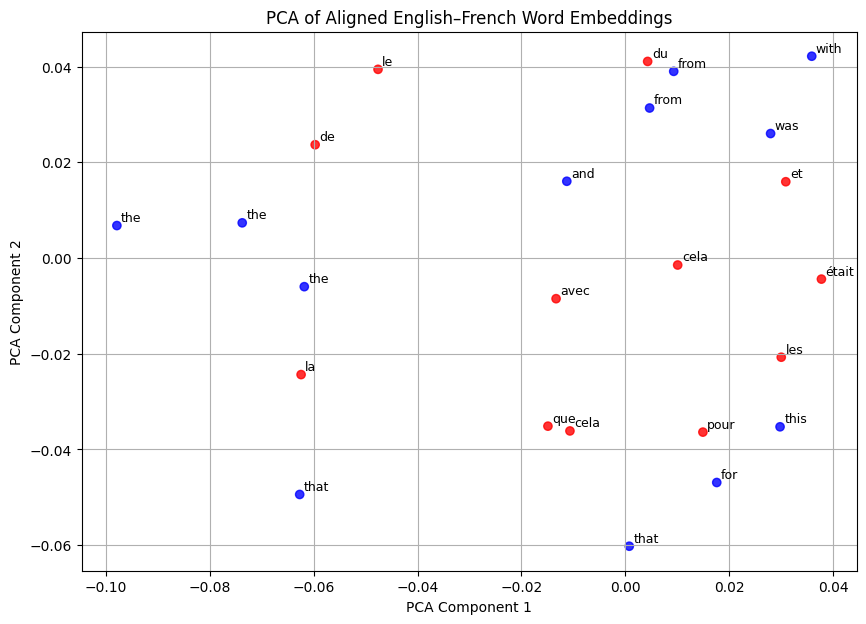

In [ ]:
# =========================
# PCA Visualization 
# =========================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Limit number of pairs to avoid clutter
viz_pairs = bilingual_pairs[:12]

labels = []
vectors = []
colors = []

for en_word, fr_word in viz_pairs:
    labels.append(en_word)
    vectors.append(np.dot(w2v_en.wv[en_word], R))
    colors.append("blue")

    labels.append(fr_word)
    vectors.append(w2v_fr.wv[fr_word])
    colors.append("red")

vectors = np.array(vectors)

# PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

# Add small jitter to avoid overlap
jitter = np.random.normal(0, 0.02, reduced.shape)
reduced = reduced + jitter

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(reduced[:, 0], reduced[:, 1], c=colors, alpha=0.8)

for i, label in enumerate(labels):
    plt.annotate(
        label,
        (reduced[i, 0], reduced[i, 1]),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=9
    )

plt.title("PCA of Aligned English–French Word Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


**Synonyms & Antonyms (English, Word2Vec)**

In [ ]:
# =========================
# Synonyms & Antonyms (English)
# =========================

# Synonym candidates
syn_word = "good"
ant_word = "bad"

# Check presence
if syn_word in w2v_en.wv and ant_word in w2v_en.wv:
    synonyms = w2v_en.wv.most_similar(syn_word, topn=5)
    similarity_syn = w2v_en.wv.similarity(syn_word, "nice") if "nice" in w2v_en.wv else None
    similarity_ant = w2v_en.wv.similarity(syn_word, ant_word)

    print("Top similar words to 'good':")
    for w, s in synonyms:
        print(f"{w}: {s:.3f}")

    print("\nSimilarity(good, nice):", similarity_syn)
    print("Similarity(good, bad):", similarity_ant)
else:
    print("Required words not in vocabulary.")


Top similar words to 'good':
pretty: 0.326
lovely: 0.326
you: 0.322
this: 0.314
of: 0.303

Similarity(good, nice): 0.07686403
Similarity(good, bad): -0.01882504


**Common Words Across Languages (EN–FR)**

In [ ]:
# =========================
# Common Words Across Languages
# =========================

common_pairs = [
    ("the", "le"),
    ("and", "et"),
    ("for", "pour"),
    ("with", "avec")
]

print("Cosine similarity (aligned space):")
for en_word, fr_word in common_pairs:
    if en_word in w2v_en.wv and fr_word in w2v_fr.wv:
        sim = muse_similarity(en_word, fr_word)
        print(f"{en_word} ↔ {fr_word}: {sim:.3f}")


Cosine similarity (aligned space):
the ↔ le: 0.786
and ↔ et: 0.683
for ↔ pour: 0.788
with ↔ avec: 0.717


**Polysemy (Bank Example)**

In [ ]:
# =========================
# Polysemy Analysis
# =========================

poly_word = "bank"

if poly_word in w2v_en.wv:
    similar_words = w2v_en.wv.most_similar(poly_word, topn=10)

    print("Top contexts for 'bank':")
    for w, s in similar_words:
        print(f"{w}: {s:.3f}")
else:
    print("'bank' not in vocabulary.")


'bank' not in vocabulary.


**Rare Words / OOV Handling**

In [ ]:
# =========================
# Rare / OOV Handling Comparison
# =========================

rare_word = "unhappinessxyz"

print("Word2Vec contains word?", rare_word in w2v_en.wv)
print("GloVe contains word?", rare_word in glove_vocab_en)
print("FastText contains word?", rare_word in ft_en.wv)

if rare_word in ft_en.wv:
    print("FastText vector (first 5 values):", ft_en.wv[rare_word][:5])


Word2Vec contains word? False
GloVe contains word? False
FastText contains word? True
FastText vector (first 5 values): [-0.00118518 -0.00115146 -0.00038383 -0.00022774 -0.00130534]


**Downstream Classifier**

In [ ]:
# =========================
# Downstream Task: Language Identification
# =========================

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Sentence embedding (average FastText vectors)
def sentence_embedding(sentence, model):
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# Build dataset
X = []
y = []

for sent in english_tokens:
    X.append(sentence_embedding(sent, ft_en))
    y.append("EN")

for sent in french_tokens:
    X.append(sentence_embedding(sent, ft_fr))
    y.append("FR")

X = np.array(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

          EN       0.99      1.00      1.00       150
          FR       1.00      0.99      1.00       150

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

